# Sentiment Analysis - Study 3

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import json
import re
from transformers import pipeline
from tqdm import tqdm
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

/opt/homebrew/Caskroom/miniforge/base/envs/tft/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tqdm.pandas()

## Reading & cleaning the LLM responses

In [3]:
df = pd.read_csv('./data/ageRisk_complete.csv', index_col=0)

## Feature engineering

In [ ]:
def get_oneshot_classes(df, classes, col, prefix):
    for label in classes:
        df[f'{prefix}-{label}'] = df[col].apply(lambda x: x['scores'][x['labels'].index(label)])
    return df

### Presence of a disclaimer

In [ ]:
zero_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
candidates_disclaimer = ['disclaimer', 'no disclaimer']

df_disclaimer = df.copy()
df_disclaimer['disclaimer_raw'] = df_disclaimer['raw'].progress_apply(lambda res: zero_classifier(res, candidates_disclaimer))

In [ ]:
df_disclaimer = get_oneshot_classes(df_disclaimer, candidates_disclaimer, 'disclaimer_raw', 'disclaim')
df = df_disclaimer

### Presence of explanations

In [ ]:
candidates_explanations = ['explanations', 'no explanations']

df_explanations = df.copy()
df_explanations['explanations_raw'] = df_explanations['raw'].progress_apply(lambda res: zero_classifier(res, candidates_explanations))

In [ ]:
df_explanations = get_oneshot_classes(df_explanations, candidates_explanations, 'explanations_raw', 'explain')
df = df_explanations

### Assertiveness

In [ ]:
candidates_assertive = ['assertive', 'non-assertive']

df_assertive = df.copy()
df_assertive['assertiveness_raw'] = df_assertive['raw'].progress_apply(lambda res: zero_classifier(res, candidates_assertive))

In [ ]:
df_assertive = get_oneshot_classes(df_assertive, candidates_assertive, 'assertiveness_raw', 'assertive')
df = df_assertive

In [ ]:
df.to_csv('./data/sentiment_features.csv')

## Analysis

In [23]:
df = pd.read_csv('./data/sentiment_features.csv', index_col=0)
df.columns = df.columns.str.replace('-', '_').str.replace(' ', '_')
df['cond'] = df['cond'].replace({'control': 'Control prompt','engineered': 'Goal prompt'})
df['risk_taking'] = df['risk_taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})

In [65]:
label_dict = {'ai':'GenAI', 'age':'Age', 'risk_taking':'Risk Tendency'}
rename_dict = {
    'disclaim_disclaimer' : 'Disclaimer',
    'disclaim_no_disclaimer':'No Disclaimer',
    'assertive_assertive':'Assertiveness',
    'assertive_non_assertive':'Non-Assertiveness',
    'explain_explanations':'Rationality',
    'explain_no_explanations':'Non-Rationality',  
}   

def show_colmeans(df, starter):
    for column_name in df.columns:
        if column_name.startswith(starter):
            print(f'mean for column {rename_dict[column_name]}: {round(df[column_name].mean(), 4)} with length: {df[column_name].size}')

def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
def show_errplot(raw, column, column_label, group1, group2=None):
    if group1 == 'risk_taking':
        order = ['low', 'medium', 'high']
        raw[group1] = pd.Categorical(raw[group1], categories=order, ordered=True)
        raw.sort_values(by=group1, inplace=True)
        
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]
    
    grouped = raw.groupby(groups, observed=False)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)
    
    plt.clf()
    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
        
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 4), zorder=2, color=colors)
    ax.set_ylabel(rename_dict[column_label])
    x_label = 'Condition' if group1 == 'cond' else label_dict.get(group1, group1)
    ax.set_xlabel(x_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.grid(True, zorder=1)
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2)
        legend.get_title().set_text(group2)

    group2_label = f'-{group2}' if group2 != None else ''
    plt.savefig(f'./figures/sentiment/{group1}{group2_label}-{column_label}.png', bbox_inches='tight')
    
def show_model_details(df, starter, group1, group2=None):
    for column_name in df.columns:
        if column_name.startswith(starter):            
            show_errplot(df, column_name, column_name, group1, group2)
            plt.show()

### Disclaimer

In [66]:
show_colmeans(df, 'disclaim_')

mean for column Disclaimer: 0.9403 with length: 180
mean for column No Disclaimer: 0.0597 with length: 180


            sum_sq     df         F    PR(>F)
label     0.033660    1.0  13.89582  0.000259
Residual  0.431167  178.0       NaN       NaN
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2   meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------
Control prompt Goal prompt  -0.0273 0.0003 -0.0418 -0.0129   True
-----------------------------------------------------------------
means:
cond
Control prompt    0.9540
Goal prompt       0.9266
Name: disclaim_disclaimer, dtype: float64
stds:
cond
Control prompt    0.044
Goal prompt       0.054
Name: disclaim_disclaimer, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: disclaim_disclaimer, dtype: int64


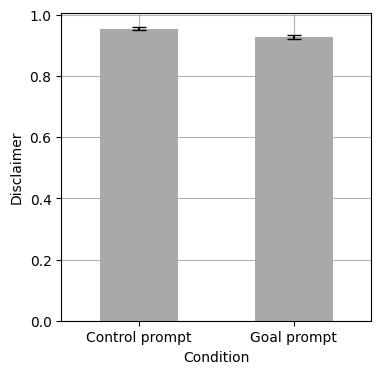

            sum_sq     df          F    PR(>F)
label     0.033660    1.0  13.895822  0.000259
Residual  0.431167  178.0        NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj  lower  upper  reject
---------------------------------------------------------------
Control prompt Goal prompt   0.0273 0.0003 0.0129 0.0418   True
---------------------------------------------------------------
means:
cond
Control prompt    0.0460
Goal prompt       0.0734
Name: disclaim_no_disclaimer, dtype: float64
stds:
cond
Control prompt    0.044
Goal prompt       0.054
Name: disclaim_no_disclaimer, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: disclaim_no_disclaimer, dtype: int64


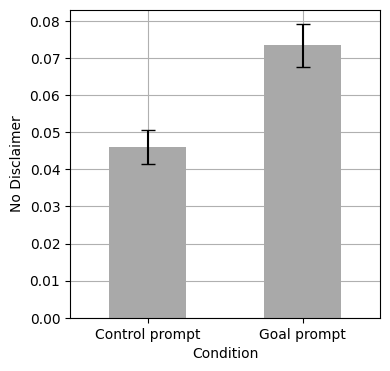

In [67]:
show_model_details(df, 'disclaim_', 'cond')

            sum_sq     df        F   PR(>F)
label     0.002655    1.0  1.02237  0.31333
Residual  0.462172  178.0      NaN      NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0054 0.8305 -0.0166 0.0274  False
    15     50  -0.0085 0.6307 -0.0305 0.0135  False
    30     50  -0.0139 0.2947 -0.0359 0.0081  False
---------------------------------------------------
means:
age
15    0.9413
30    0.9467
50    0.9328
Name: disclaim_disclaimer, dtype: float64
stds:
age
15    0.0505
30    0.0455
50    0.0562
Name: disclaim_disclaimer, dtype: float64
age
15    60
30    60
50    60
Name: disclaim_disclaimer, dtype: int64


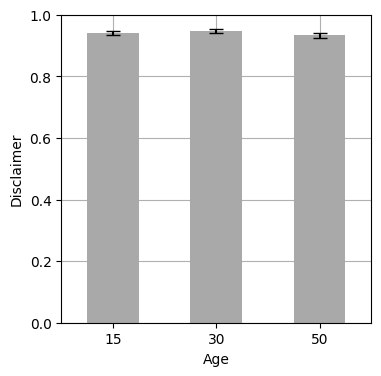

            sum_sq     df         F   PR(>F)
label     0.002655    1.0  1.022368  0.31333
Residual  0.462172  178.0       NaN      NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0054 0.8305 -0.0274 0.0166  False
    15     50   0.0085 0.6307 -0.0135 0.0305  False
    30     50   0.0139 0.2947 -0.0081 0.0359  False
---------------------------------------------------
means:
age
15    0.0587
30    0.0533
50    0.0672
Name: disclaim_no_disclaimer, dtype: float64
stds:
age
15    0.0505
30    0.0455
50    0.0562
Name: disclaim_no_disclaimer, dtype: float64
age
15    60
30    60
50    60
Name: disclaim_no_disclaimer, dtype: int64


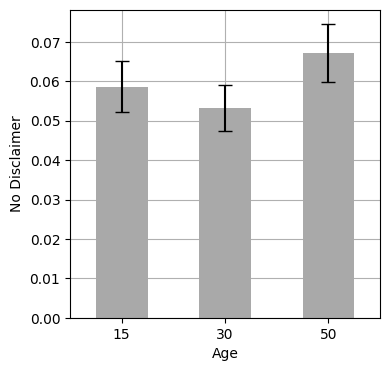

In [68]:
show_model_details(df, 'disclaim_', 'age')

            sum_sq     df         F    PR(>F)
label     0.038970    2.0  8.098618  0.000431
Residual  0.425856  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -0.0348 0.0004  -0.056 -0.0136   True
  high medium  -0.0093 0.5563 -0.0304  0.0119  False
   low medium   0.0255 0.0135  0.0044  0.0467   True
----------------------------------------------------
means:
risk_taking
low       0.9202
medium    0.9457
high      0.9550
Name: disclaim_disclaimer, dtype: float64
stds:
risk_taking
low       0.0594
medium    0.0418
high      0.0441
Name: disclaim_disclaimer, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: disclaim_disclaimer, dtype: int64


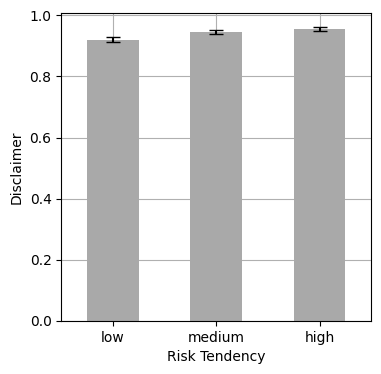

            sum_sq     df         F    PR(>F)
label     0.038970    2.0  8.098621  0.000431
Residual  0.425856  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low   0.0348 0.0004  0.0136   0.056   True
  high medium   0.0093 0.5563 -0.0119  0.0304  False
   low medium  -0.0255 0.0135 -0.0467 -0.0044   True
----------------------------------------------------
means:
risk_taking
low       0.0798
medium    0.0543
high      0.0450
Name: disclaim_no_disclaimer, dtype: float64
stds:
risk_taking
low       0.0594
medium    0.0418
high      0.0441
Name: disclaim_no_disclaimer, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: disclaim_no_disclaimer, dtype: int64


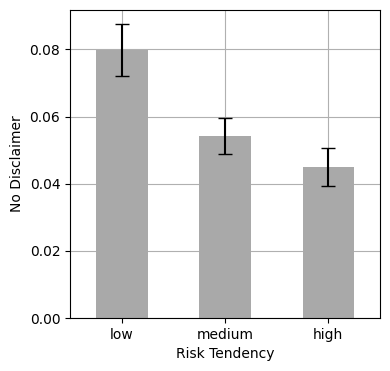

In [69]:
show_model_details(df, 'disclaim_', 'risk_taking')

            sum_sq     df         F    PR(>F)
label     0.076504    5.0  6.856006  0.000007
Residual  0.388322  174.0       NaN       NaN
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                   group2          meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------
  (Control prompt, high)    (Control prompt, low)  -0.0439 0.0055 -0.0791 -0.0088   True
  (Control prompt, high) (Control prompt, medium)  -0.0079 0.9868 -0.0431  0.0272  False
  (Control prompt, high)      (Goal prompt, high)  -0.0325  0.087 -0.0677  0.0026  False
  (Control prompt, high)       (Goal prompt, low)  -0.0582 0.0001 -0.0934 -0.0231   True
  (Control prompt, high)    (Goal prompt, medium)  -0.0431 0.0068 -0.0783  -0.008   True
   (Control prompt, low) (Control prompt, medium)    0.036 0.0416  0.0008  0.0711   True
   (Control prompt, low)      (Goal prompt, high)   0.0114 0.

<Figure size 640x480 with 0 Axes>

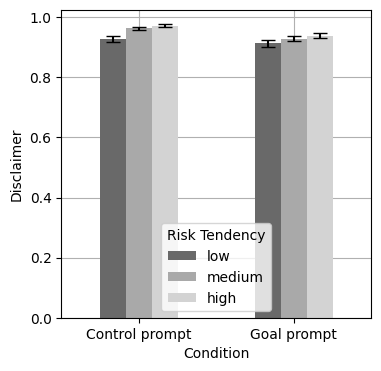

            sum_sq     df         F    PR(>F)
label     0.076504    5.0  6.856008  0.000007
Residual  0.388322  174.0       NaN       NaN
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                   group2          meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------
  (Control prompt, high)    (Control prompt, low)   0.0439 0.0055  0.0088  0.0791   True
  (Control prompt, high) (Control prompt, medium)   0.0079 0.9868 -0.0272  0.0431  False
  (Control prompt, high)      (Goal prompt, high)   0.0325  0.087 -0.0026  0.0677  False
  (Control prompt, high)       (Goal prompt, low)   0.0582 0.0001  0.0231  0.0934   True
  (Control prompt, high)    (Goal prompt, medium)   0.0431 0.0068   0.008  0.0783   True
   (Control prompt, low) (Control prompt, medium)   -0.036 0.0416 -0.0711 -0.0008   True
   (Control prompt, low)      (Goal prompt, high)  -0.0114 0.

<Figure size 640x480 with 0 Axes>

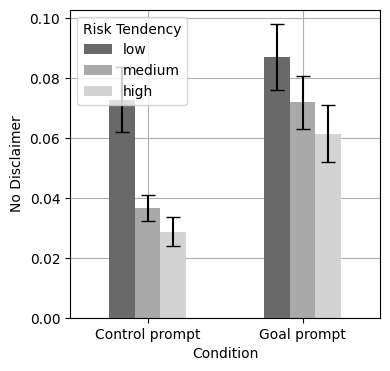

In [70]:
show_model_details(df, 'disclaim_', 'cond', 'risk_taking')

### Explanations

In [71]:
show_colmeans(df, 'explain_')

mean for column Rationality: 0.9535 with length: 180
mean for column Non-Rationality: 0.0465 with length: 180


            sum_sq     df         F    PR(>F)
label     0.005733    1.0  7.828568  0.005709
Residual  0.130353  178.0       NaN       NaN
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2   meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------
Control prompt Goal prompt  -0.0113 0.0057 -0.0192 -0.0033   True
-----------------------------------------------------------------
means:
cond
Control prompt    0.9591
Goal prompt       0.9479
Name: explain_explanations, dtype: float64
stds:
cond
Control prompt    0.0245
Goal prompt       0.0294
Name: explain_explanations, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: explain_explanations, dtype: int64


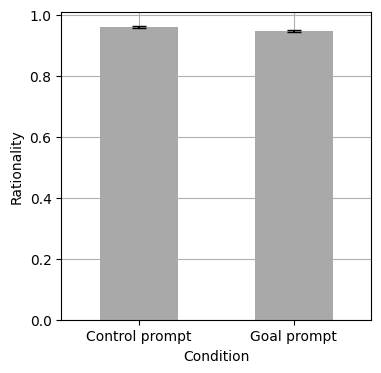

            sum_sq     df        F    PR(>F)
label     0.005733    1.0  7.82857  0.005709
Residual  0.130353  178.0      NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj  lower  upper  reject
---------------------------------------------------------------
Control prompt Goal prompt   0.0113 0.0057 0.0033 0.0192   True
---------------------------------------------------------------
means:
cond
Control prompt    0.0409
Goal prompt       0.0521
Name: explain_no_explanations, dtype: float64
stds:
cond
Control prompt    0.0245
Goal prompt       0.0294
Name: explain_no_explanations, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: explain_no_explanations, dtype: int64


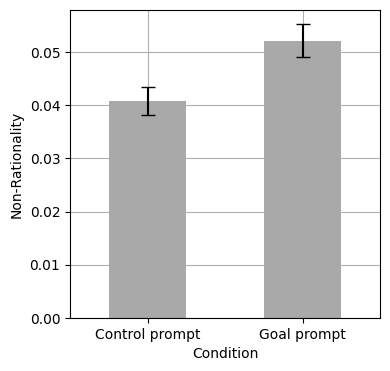

In [72]:
show_model_details(df, 'explain_', 'cond')

            sum_sq     df       F    PR(>F)
label     0.000381    1.0  0.4991  0.480819
Residual  0.135705  178.0     NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0001 0.9997 -0.0121 0.0118  False
    15     50  -0.0034 0.7772 -0.0154 0.0085  False
    30     50  -0.0033 0.7896 -0.0153 0.0086  False
---------------------------------------------------
means:
age
15    0.9547
30    0.9546
50    0.9513
Name: explain_explanations, dtype: float64
stds:
age
15    0.0316
30    0.0209
50    0.0294
Name: explain_explanations, dtype: float64
age
15    60
30    60
50    60
Name: explain_explanations, dtype: int64


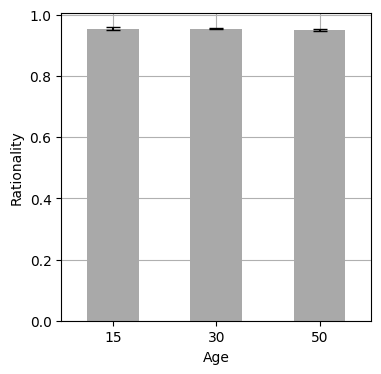

            sum_sq     df       F   PR(>F)
label     0.000381    1.0  0.4991  0.48082
Residual  0.135705  178.0     NaN      NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0001 0.9997 -0.0118 0.0121  False
    15     50   0.0034 0.7772 -0.0085 0.0154  False
    30     50   0.0033 0.7896 -0.0086 0.0153  False
---------------------------------------------------
means:
age
15    0.0453
30    0.0454
50    0.0487
Name: explain_no_explanations, dtype: float64
stds:
age
15    0.0316
30    0.0209
50    0.0294
Name: explain_no_explanations, dtype: float64
age
15    60
30    60
50    60
Name: explain_no_explanations, dtype: int64


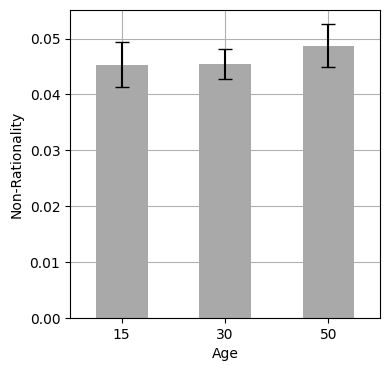

In [73]:
show_model_details(df, 'explain_', 'age')

            sum_sq     df         F    PR(>F)
label     0.000633    2.0  0.413698  0.661838
Residual  0.135452  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low  -0.0016 0.9493 -0.0135 0.0104  False
  high medium    0.003 0.8269  -0.009 0.0149  False
   low medium   0.0045 0.6441 -0.0074 0.0165  False
---------------------------------------------------
means:
risk_taking
low       0.9515
medium    0.9560
high      0.9530
Name: explain_explanations, dtype: float64
stds:
risk_taking
low       0.0359
medium    0.0207
high      0.0241
Name: explain_explanations, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: explain_explanations, dtype: int64


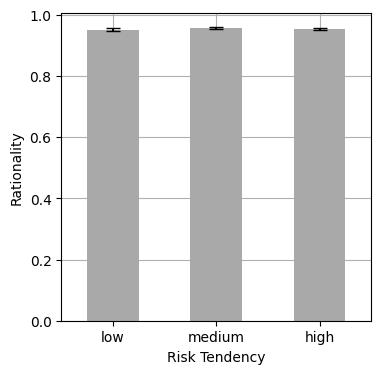

            sum_sq     df         F   PR(>F)
label     0.000633    2.0  0.413696  0.66184
Residual  0.135452  177.0       NaN      NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low   0.0016 0.9493 -0.0104 0.0135  False
  high medium   -0.003 0.8269 -0.0149  0.009  False
   low medium  -0.0045 0.6441 -0.0165 0.0074  False
---------------------------------------------------
means:
risk_taking
low       0.0485
medium    0.0440
high      0.0470
Name: explain_no_explanations, dtype: float64
stds:
risk_taking
low       0.0359
medium    0.0207
high      0.0241
Name: explain_no_explanations, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: explain_no_explanations, dtype: int64


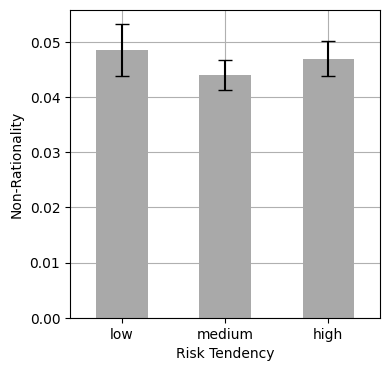

In [74]:
show_model_details(df, 'explain_', 'risk_taking')

### Assertiveness

In [75]:
show_colmeans(df, 'assertive_')

mean for column Assertiveness: 0.6299 with length: 180
mean for column Non-Assertiveness: 0.3701 with length: 180


            sum_sq     df         F    PR(>F)
label     0.051829    1.0  4.568224  0.033935
Residual  2.019522  178.0       NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj  lower  upper  reject
---------------------------------------------------------------
Control prompt Goal prompt   0.0339 0.0339 0.0026 0.0653   True
---------------------------------------------------------------
means:
cond
Control prompt    0.6129
Goal prompt       0.6469
Name: assertive_assertive, dtype: float64
stds:
cond
Control prompt    0.1062
Goal prompt       0.1068
Name: assertive_assertive, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: assertive_assertive, dtype: int64


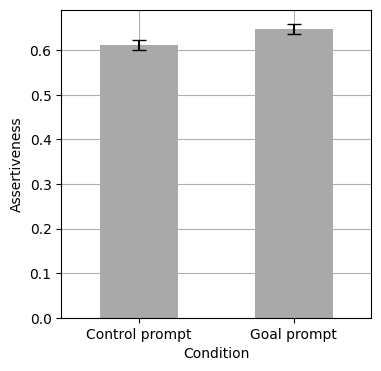

            sum_sq     df         F    PR(>F)
label     0.051829    1.0  4.568223  0.033935
Residual  2.019522  178.0       NaN       NaN
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2   meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------
Control prompt Goal prompt  -0.0339 0.0339 -0.0653 -0.0026   True
-----------------------------------------------------------------
means:
cond
Control prompt    0.3871
Goal prompt       0.3531
Name: assertive_non_assertive, dtype: float64
stds:
cond
Control prompt    0.1062
Goal prompt       0.1068
Name: assertive_non_assertive, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: assertive_non_assertive, dtype: int64


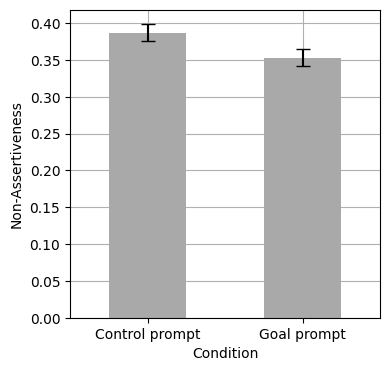

In [76]:
show_model_details(df, 'assertive_', 'cond')

            sum_sq     df         F    PR(>F)
label     0.008544    1.0  0.737279  0.391689
Residual  2.062807  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0133  0.777 -0.0599 0.0332  False
    15     50  -0.0174 0.6524 -0.0639 0.0292  False
    30     50   -0.004 0.9772 -0.0506 0.0425  False
---------------------------------------------------
means:
age
15    0.6402
30    0.6268
50    0.6228
Name: assertive_assertive, dtype: float64
stds:
age
15    0.1066
30    0.0968
50    0.1192
Name: assertive_assertive, dtype: float64
age
15    60
30    60
50    60
Name: assertive_assertive, dtype: int64


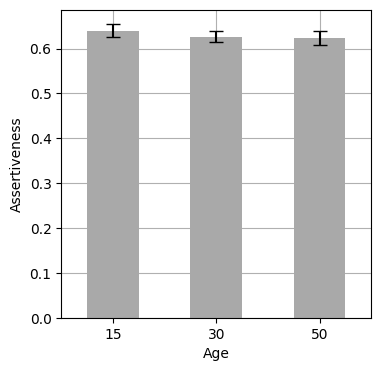

            sum_sq     df         F    PR(>F)
label     0.008544    1.0  0.737279  0.391689
Residual  2.062807  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0133  0.777 -0.0332 0.0599  False
    15     50   0.0174 0.6524 -0.0292 0.0639  False
    30     50    0.004 0.9772 -0.0425 0.0506  False
---------------------------------------------------
means:
age
15    0.3598
30    0.3732
50    0.3772
Name: assertive_non_assertive, dtype: float64
stds:
age
15    0.1066
30    0.0968
50    0.1192
Name: assertive_non_assertive, dtype: float64
age
15    60
30    60
50    60
Name: assertive_non_assertive, dtype: int64


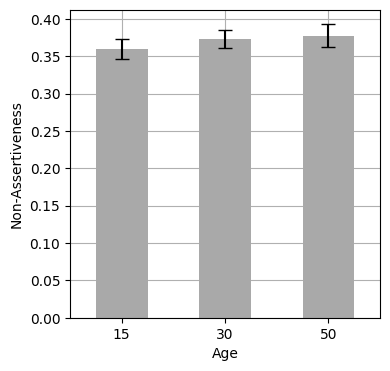

In [77]:
show_model_details(df, 'assertive_', 'age')

            sum_sq     df         F    PR(>F)
label     0.015999    2.0  0.688888  0.503475
Residual  2.055352  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low  -0.0231 0.4704 -0.0696 0.0234  False
  high medium  -0.0117 0.8232 -0.0582 0.0348  False
   low medium   0.0114 0.8315 -0.0351 0.0579  False
---------------------------------------------------
means:
risk_taking
low       0.6184
medium    0.6298
high      0.6415
Name: assertive_assertive, dtype: float64
stds:
risk_taking
low       0.1124
medium    0.0998
high      0.1106
Name: assertive_assertive, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: assertive_assertive, dtype: int64


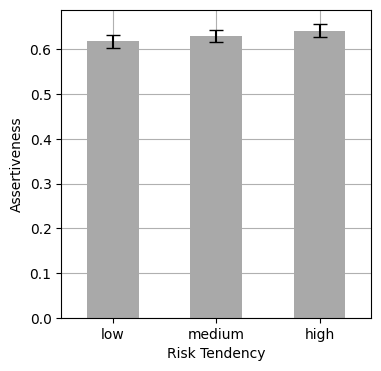

            sum_sq     df         F    PR(>F)
label     0.015999    2.0  0.688888  0.503475
Residual  2.055352  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low   0.0231 0.4704 -0.0234 0.0696  False
  high medium   0.0117 0.8232 -0.0348 0.0582  False
   low medium  -0.0114 0.8315 -0.0579 0.0351  False
---------------------------------------------------
means:
risk_taking
low       0.3816
medium    0.3702
high      0.3585
Name: assertive_non_assertive, dtype: float64
stds:
risk_taking
low       0.1124
medium    0.0998
high      0.1106
Name: assertive_non_assertive, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: assertive_non_assertive, dtype: int64


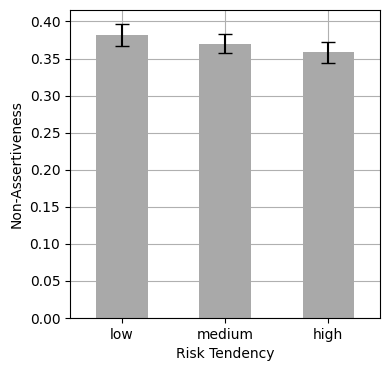

In [78]:
show_model_details(df, 'assertive_', 'risk_taking')